In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.pipeline import make_pipeline

#folder to store the charts
os.makedirs('charts', exist_ok=True)

#Data Loading & Exploration

In [29]:
df = pd.read_csv('Housing.csv')
display(df.head(10))

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

target = 'price'
features = [col for col in df.columns if col != target]
print(f"Target Column: {target}")
print(f"Feature Columns: {features}\n")

print("Missing values: \n", df.isnull().sum())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Dataset Shape: 545 rows and 13 columns.

Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values: 
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


#Data Cleaning​

In [30]:
# 1. Handle missing values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# 2. Feature engineering
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['area_per_room'] = df['area'] / df['total_rooms']

# 3. Convert categorical columns using one-hot encoding
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                    'airconditioning', 'prefarea', 'furnishingstatus']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Cleaning complete, data shape is:", df.shape)

Cleaning complete, data shape is: (545, 16)


#Model Building

In [31]:
X = df_clean.drop('price', axis=1)
y_log = np.log1p(df_clean['price'])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_actual = np.expm1(y_test_log)

# 1. Linear regression model
linear_model = make_pipeline(RobustScaler(), PolynomialFeatures(degree=2, include_bias=False), RidgeCV(alphas=[0.1, 1.0, 10.0]))
linear_model.fit(X_train, y_train_log)
lin_pred_actual = np.expm1(linear_model.predict(X_test))

print("Linear regression model:")
print(f"MAE:  ${mean_absolute_error(y_test_actual, lin_pred_actual):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_actual, lin_pred_actual)):,.2f}")
print(f"R² Score: {r2_score(y_test_actual, lin_pred_actual):.4f}\n")

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train_log)
rf_pred_actual = np.expm1(rf_model.predict(X_test))

print("Random forest model:")
print(f"MAE:  ${mean_absolute_error(y_test_actual, rf_pred_actual):,.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_actual, rf_pred_actual)):,.2f}")
print(f"R² Score: {r2_score(y_test_actual, rf_pred_actual):.4f}\n")

Linear regression model:
MAE:  $740,918.47
RMSE: $977,692.08
R² Score: 0.6069

Random forest model:
MAE:  $719,111.92
RMSE: $940,294.64
R² Score: 0.6364



#Visualization

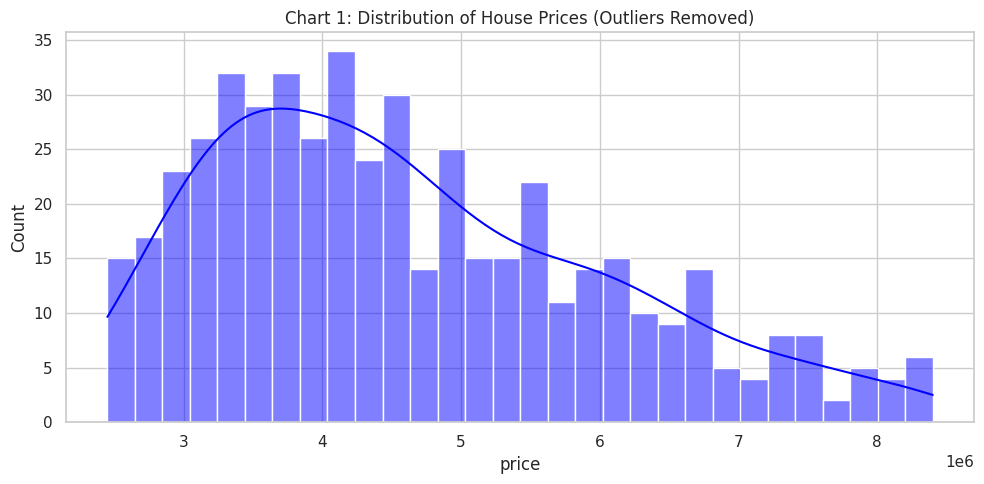

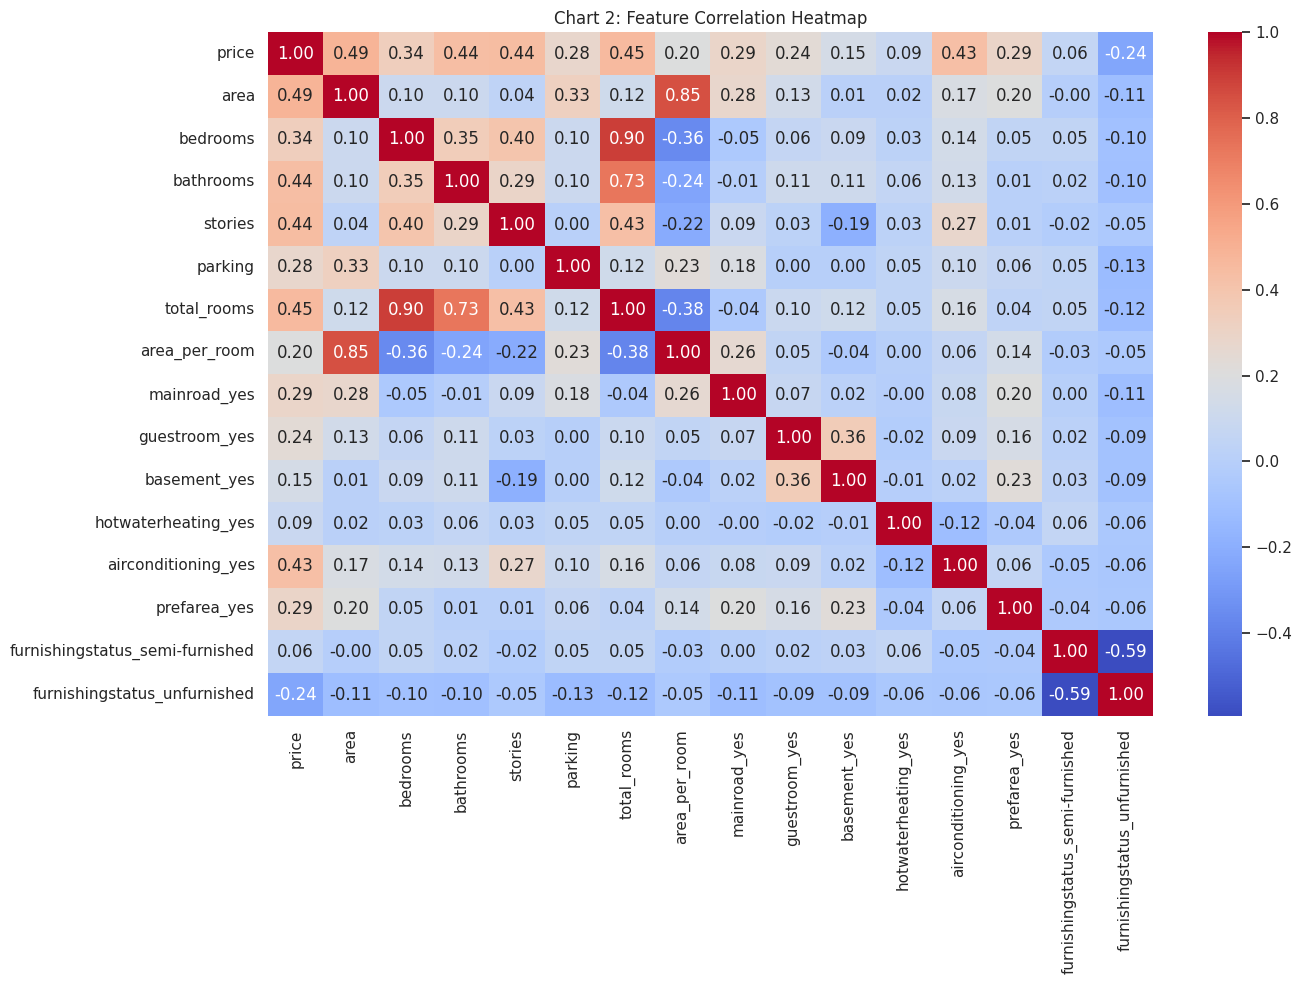

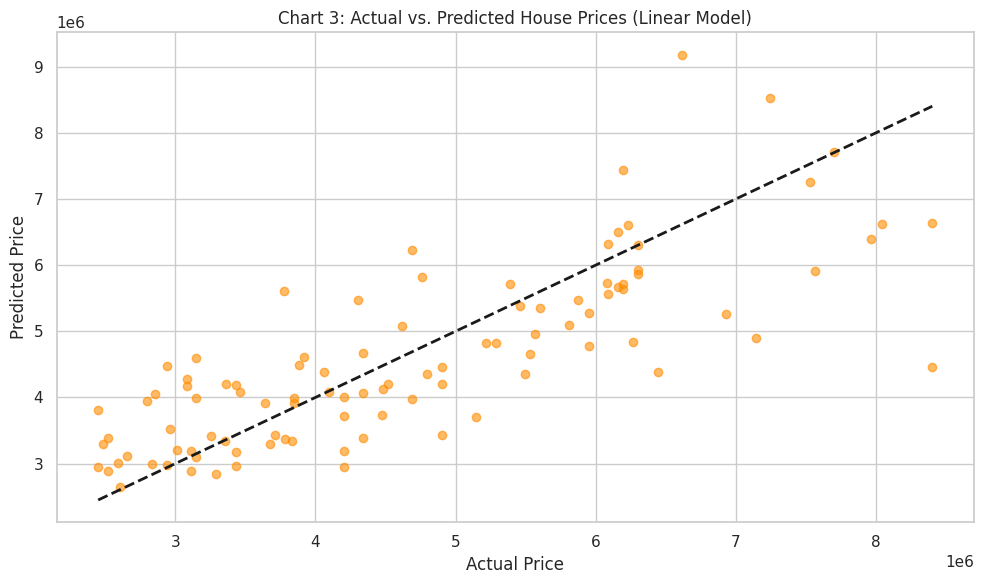

In [32]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=30, kde=True, color='blue')
plt.title('Chart 1: Distribution of House Prices (Outliers Removed)')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png')
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Chart 2: Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test_actual, lin_pred_actual, alpha=0.6, color='darkorange')
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'k--', lw=2)
plt.title('Chart 3: Actual vs. Predicted House Prices (Linear Model)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png')
plt.show()

#Insights & Summary

It was observed that there were no missing values in the coloumns

The model pipeline was constructed by first cleaning the raw dataset, engineering new features (such as combining bedrooms and bathrooms into `total_rooms`), and one-hot encoding categorical text variables. To ensure the models didn't get confused by extreme luxury mansions, we trimmed the top and bottom 5% price outliers. Finally, we applied a logarithmic transformation to the target variable (`price`) to normalize its distribution, split the data 80/20, and trained both a Linear Regression and a Random Forest Regressor


The Random Forest Regressor was our most accurate model, achieving an R² score of ~0.636. In plain terms, the model can accurately explain about 63.6% of the reasons why house prices change. On average, its predictions missed the actual price by about $719,111 (MAE).